## Source-to-tutorial coverage map

| Original file | This tutorial |
| --- | --- |
| `simulator.mlapp` | `simulate_scene_dataset_tutorial`, end-to-end sections |
| `funcs/acSim/acSim.m` | `acsim_tutorial` |
| `funcs/acSim/extern/helperFrequencyOffset.m` | `helper_frequency_offset` |
| `funcs/acSim/extern/vhtNoiseEstimate.m` | `vht_noise_estimate_tutorial` |
| `funcs/acSim/extern/vhtSingleStreamChannelEstimate.m` | `vht_single_stream_channel_estimate_tutorial` |
| `funcs/getFeature/naive_aoa.m` | `naive_aoa_ch2` |
| `funcs/getFeature/naive_tof.m` | `naive_tof_ch2` |
| `funcs/getFeature/naive_spectrum.m` | `naive_spectrum_ch2` |
| `funcs/getFeature/grid_search_aoa.m` | `grid_search_aoa_ch2` |
| `funcs/getFeature/grid_search_tof.m` | `grid_search_tof_ch2` |
| `funcs/getFeature/mD-Track/compute_AOA.m` | `compute_aoa_mdtrack` |
| `funcs/getFeature/mD-Track/compute_AOD.m` | `compute_aod_mdtrack` |
| `funcs/getFeature/mD-Track/compute_TOF.m` | `compute_tof_mdtrack` |
| `funcs/getFeature/mD-Track/mD_track.m` | `md_track` |

## What is preserved and what is substituted

Preserved:
- tensor shapes and CSI intuition
- AoA / ToF / STFT feature logic
- grid search logic
- mD-Track style iterative path estimation
- the idea of packet -> channel -> CSI estimation

Substituted:
- MATLAB App Designer UI
- MATLAB WLAN toolbox packet generation
- MATLAB ray tracing and RF site objects

Those are replaced with a tutorial-grade OFDM + multipath simulator that can run in plain Python.

In [67]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import math
import json
import os
import numpy as np

In [68]:
CACHE_DIR = Path.cwd() / ".cache"
CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR))

MPL_CACHE_DIR = Path.cwd() / ".matplotlib"
MPL_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))

'/Users/codingtai/Documents/ml_dl/wifi-sensing-learning/chapter2/notebooks/.matplotlib'

In [69]:
# try:
#   import matplotlib
#   matplotlib.use("Agg")
#   import matplotlib.pyplot as plt
#   MATPLOTLIB_AVAILABLE = True
# except Exception:
#   MATPLOTLIB_AVAILABLE = False

# try:
#   from scipy.io import loadmat
#   SCIPY_AVAILABLE = True
# except Exception:
#   SCIPY_AVAILABLE = False

In [122]:
%matplotlib inline

In [125]:
try:
  import matplotlib
  try:
    from IPython import get_ipython
  except Exception:
    get_ipython = None
  
  ip = get_ipython() if get_ipython is not None else None

  if ip is None:
    matplotlib.use("Agg")
  else:
    try:
      ip.run_line_magic("matplotlib", "inline")
    except Exception:
      pass
  
  import matplotlib.pyplot as plt
  MATPLOTLIB_AVAILABLE = True

except Exception:
  MATPLOTLIB_AVAILABLE = False


try:
  from scipy.io import loadmat
  SCIPY_AVAILABLE = True
except Exception:
  SCIPY_AVAILABLE = False

In [71]:
DATASET_MAT = Path("../data/dataset.mat")

## Environment status

This cell tells you whether the optional packages needed for file loading and plotting are available.

In [72]:
print("SciPy available:", SCIPY_AVAILABLE)
print("Matplotlib available:", MATPLOTLIB_AVAILABLE)
print("dataset.mat exists:", DATASET_MAT.exists())

SciPy available: True
Matplotlib available: True
dataset.mat exists: True


## Constants and geometry helpers

The MATLAB simulator uses 5.8 GHz Wi-Fi and a 2x2 receive array. We keep the same basic geometry here.

In [73]:
C = 299_792_458.0

In [74]:
CENTER_FREQ = 5.8e9

In [75]:
DEFAULT_BW = 20e6

In [76]:
DEFAULT_NUM_SUBCARRIERS = 56

**Wavelength**

In [77]:
def wavelength(freq_hz: float) -> float:
  return C / freq_hz

**Subcarrier frequency**

In [78]:
def subcarrier_freqs(
  center_freq: float = CENTER_FREQ, 
  bandwidth_hz: float = DEFAULT_BW, 
  num_subcarriers: int = DEFAULT_NUM_SUBCARRIERS
) -> np.ndarray:
  
  return np.linspace(
    center_freq - bandwidth_hz / 2, 
    center_freq + bandwidth_hz / 2, 
    num_subcarriers
  )

**Subcarrier Wavelength**

In [79]:
def subcarrier_lambdas(
  center_freq: float = CENTER_FREQ, 
  bandwidth_hz: float = DEFAULT_BW, 
  num_subcarriers: int = DEFAULT_NUM_SUBCARRIERS
) -> np.ndarray:
  
  return C / subcarrier_freqs(center_freq, bandwidth_hz, num_subcarriers)

**Rx Array $2\times2$**

| Antenna | x | y | z |
| ------- | - | - | - |
| RX0     | 0 | 0 | 0 |
| RX1     | d | 0 | 0 |
| RX2     | 0 | d | 0 |
| RX3     | d | d | 0 |


2x2 planar array:

In [80]:
def rx_array_2x2(
  freq_hz: float = CENTER_FREQ
) -> np.ndarray:
  d = wavelength(freq_hz) / 2.0
  return np.array(
    [
      [0.0, d, 0.0, d],
      [0.0, 0.0, d, d],
      [0.0, 0.0, 0.0, 0.0],
    ]
  )

In [81]:
RX_ARRAY = rx_array_2x2()

In [82]:
RX_ARRAY

array([[0.        , 0.02584418, 0.        , 0.02584418],
       [0.        , 0.        , 0.02584418, 0.02584418],
       [0.        , 0.        , 0.        , 0.        ]])

## Utility helpers

This section provides notebook-native replacements for small MATLAB conveniences.

**RMS**

In [83]:
def rms(x: np.ndarray) -> float:
  return float(
    np.sqrt(
      np.mean(np.abs(x) ** 2)
    )
  )

**Add AWGN**

- Signal Power:

$$
P_{signal} = \frac{1}{N}\sum_{n=1}^{N}{|x[n]|^2}
$$

- SNR:

$$
SNR = \frac{P_{signal}}{P_{noise}}
\\
SNR_{dB} = 10\log_{10}{(\frac{P_{signal}}{P_{noise}})}
$$

- Convert SNR(dB) $\rightarrow$ linear:

$$
P_{noise} = \frac{P_{signal}}{10^{\frac{SNR_{dB}}{10}}}
$$

- Noise:

$$
noise = real + 1j \times imag
$$
where:
- real ~ $N(0, σ²)$
- imag~ $N(0, σ²)$

In [84]:
def add_awgn(
  x: np.ndarray,
  snr_db: float,
  rng: np.random.Generator
) -> np.ndarray:
  signal_power = np.mean(np.abs(x) ** 2)
  noise_power = signal_power / (10 ** (snr_db / 10.0))
  noise = (
    rng.normal(
      scale=np.sqrt(noise_power / 2),
      size=x.shape
    ) + 1j * rng.normal(
      scale=np.sqrt(noise_power / 2),
      size=x.shape
    )
  )
  return x + noise

**Hamming Window**

In [85]:
def hamming_window(n: int) -> np.ndarray:
  if n <= 1:
    return np.ones(
      (n,),
      dtype=float
    )
  idx = np.arange(n)
  return 0.54 - 0.46 * np.cos(2 * np.pi * idx / (n - 1))

**STFT**

In [86]:
def stft_numpy(
    x: np.ndarray,
    sample_rate: float,
    window_size: Optional[int] = None,
    overlap: Optional[int] = None
):
  x = np.asarray(x)

  if x.ndim == 0:
    x = x.reshape(1)
  else:
    x = x.reshape(-1)

  T = int(x.size)

  if T == 0:
    raise ValueError("Input signal must not be empty")
  
  if window_size is None:
    window_size = int(min(T, 128))
  else:
    window_size = int(window_size)

  if overlap is None:
    overlap = int(round(window_size / 2))
  else:
    overlap = int(overlap)
  
  hop = int(max(1, window_size - overlap))
  
  window = hamming_window(window_size)

  frames = []
  times = []
  for start in range(0, max(T - window_size + 1, 1), hop):
    frame = np.zeros(window_size, dtype=complex)
    cur = x[start:start + window_size]
    frame[: len(cur)] = cur
    frame = frame * window
    spectrum = np.fft.fft(frame)
    frames.append(spectrum)
    times.append(start / sample_rate)

  zxx = np.stack(frames, axis=1)
  freqs = np.fft.fftfreq(
    window_size,
    d=1.0 / sample_rate
  )
  order = np.argsort(freqs)
  return zxx[order], freqs[order], np.array(times)

In [119]:
def maybe_plot_spectrum(freqs: np.ndarray, times: np.ndarray, zxx: np.ndarray, title: str):
  if not MATPLOTLIB_AVAILABLE:
    print("Matplotlib not available, skipping plot")
    return
  
  fig, ax = plt.subplots(figsize=(8, 4))

  ax.pcolormesh(times, freqs, np.abs(zxx) ** 2, shading="auto")
  ax.set_title(title)
  ax.set_xlabel("Time (s)")
  ax.set_ylabel("Frequency (Hz)")

  fig.tight_layout()

  # plt.figure(figsize=(8, 4))
  # plt.pcolormesh(times, freqs, np.abs(zxx) ** 2, shading="auto")
  # plt.title(title)
  # plt.xlabel("Time (s)")
  # plt.ylabel("Frequency (Hz)")
  # plt.tight_layout()
  # backend = plt.get_backend().lower()
  # if backend.endswith("agg"):
  #   plt.close()
  # else:
  #   plt.show()

  try:
    from IPython.display import display
    display(fig)
  except Exception:
    plt.show()

  return fig

## Port: `helperFrequencyOffset.m`

This is a nearly exact port.
It multiplies each antenna stream by a complex exponential in time.

**Frequency Offset / Carrier Frequency Offset (CFO)**

$$
y(t) = x(t).e^{j.2\pi.t.f_{offset}}
$$

In [88]:
def helper_frequency_offset(
    x: np.ndarray,
    fs: float,
    foffset_hz: float
) -> np.ndarray:
  x = np.asarray(x)
  if x.ndim == 1:
    x = x[x, None]
  t = (np.arange(x.shape[0]) / fs).reshape(-1, 1)
  return x * np.exp(
    1j * 2 * np.pi * foffset_hz * t
  )

## Ports: `naive_aoa.m`, `naive_tof.m`, `naive_spectrum.m`

These functions operate on the CSI tensor convention used across the repo:

- `T`: packets or time samples
- `S`: subcarriers
- `A`: antennas
- `L`: extra training-field slices

So the CSI tensor shape is `[T, S, A, L]`.

**AoA Estimation (Angle of Arrival)**

In [89]:
def naive_aoa_ch2(
  csi_data: np.ndarray, 
  antenna_loc: np.ndarray, 
  est_rco: Optional[np.ndarray], 
  subcarrier_lambda: np.ndarray
) -> float:
    
  csi_phase = np.unwrap(
      np.angle(csi_data), 
      axis=1
  )
  ant_diff = antenna_loc[:, 1:] - antenna_loc[:, [0]]
  ant_diff_length = np.linalg.norm(ant_diff, axis=0)
  ant_diff_normalize = ant_diff / ant_diff_length

  ref_phase = csi_phase[:, :, [0], :]

  if est_rco is None:
    phase_diff = csi_phase[:, :, 1:, :] - ref_phase
  else:
    phase_diff = csi_phase[:, :, 1:, :] - ref_phase - est_rco[1:].reshape(1, 1, -1, 1)
  phase_diff = np.unwrap(phase_diff, axis=1)
  phase_diff = (phase_diff + np.pi) % (2 * np.pi) - np.pi

  cos_mat = subcarrier_lambda.reshape(1, -1, 1, 1) * phase_diff / (2 * np.pi * ant_diff_length.reshape(1, 1, -1, 1))
  cos_mat_mean = np.mean(cos_mat, axis=(1, 3))
  if cos_mat_mean.ndim == 1:
    cos_mat_mean = cos_mat_mean.reshape(-1, 1)

  aoa_mat_sol = np.linalg.lstsq(
    ant_diff_normalize.T, 
    cos_mat_mean.T, 
    rcond=None
  )[0]

  invalid_dim = np.where(np.isclose(ant_diff_normalize.sum(axis=1), 0))[0]
  valid_dim = np.array([i for i in range(3) if i not in invalid_dim])

  if len(invalid_dim) > 0:
    remain = 1 - np.sum(aoa_mat_sol[valid_dim, :] ** 2, axis=0)
    remain = np.clip(remain, 0, None)
    fill = np.sqrt(remain / len(invalid_dim))
    for idx in invalid_dim:
      aoa_mat_sol[idx, :] = fill

  aoa_vec = np.mean(aoa_mat_sol, axis=1)
  x, y, z = aoa_vec
  azimuth_rad = np.arctan2(y, x)
  azimuth_deg = np.degrees(azimuth_rad)
    
  if azimuth_deg > 0:
    azimuth_deg -= 180
  else:
    azimuth_deg += 180
  return float(azimuth_deg)

**ToF (Time of Flight)**

In [90]:
def naive_tof_ch2(
  csi_data: np.ndarray, 
  bw_hz: float
) -> float:
  packet_num, subcarrier_num = csi_data.shape[0], csi_data.shape[1]
  ifft_point = 2 ** int(np.ceil(np.log2(subcarrier_num)))
  cir_sequence = np.fft.ifft(csi_data, n=ifft_point, axis=1)
  cir_sequence = np.mean(cir_sequence, axis=3)
  half_point = ifft_point // 2

  if packet_num == 1:
    half_sequence = cir_sequence[0, :half_point, :]
    peak_indices = np.abs(half_sequence).argmax(axis=0)
  else:
    half_sequence = cir_sequence[:, :half_point, :]
    peak_indices = np.abs(half_sequence).argmax(axis=1)

  tof_mat = peak_indices * subcarrier_num / (ifft_point * bw_hz)
  
  return float(np.mean(tof_mat))


**Doppler Spectrum**

In [128]:
def naive_spectrum_ch2(
  csi_data: np.ndarray, 
  sample_rate: float,
  window_size: Optional[int] = None,
  overlap: Optional[int] = None
):
  # power_trace = np.mean(csi_data * np.conj(csi_data), axis=(1, 2, 3))
  # zxx, freqs, times = stft_numpy(
  #   np.real(power_trace), 
  #   sample_rate=sample_rate,
  #   window_size=window_size,
  #   overlap=overlap
  # )
  pair_trace = csi_data[:, :, 0, 0] * np.conj(csi_data[:, :, 1, 0])
  signal_trace = np.mean(
    np.unwrap(np.angle(pair_trace), axis=1),
    axis=1
  )
  zxx, freqs, times = stft_numpy(
    signal_trace, 
    sample_rate=sample_rate,
    window_size=window_size,
    overlap=overlap
  )
  return zxx, freqs, times

## Ports: `grid_search_aoa.m` and `grid_search_tof.m`

These search over candidate angle or delay values and choose the maximum correlation score.

**Grid Search AoA**

In [92]:
def grid_search_aoa_ch2(
  CSI: np.ndarray, 
  lambda_center: float, 
  lambda_list: np.ndarray
) -> float:
  ue_csi1 = CSI[:, :, 0, 0]
  ue_csi2 = CSI[:, :, 1, 0]
  ue_csi3 = CSI[:, :, 2, 0]
  csi_data1 = ue_csi3 * np.conj(ue_csi1)
  csi_data2 = ue_csi2 * np.conj(ue_csi1)

  theta_grid = np.arange(0.0, np.pi + 1e-9, np.pi / 180.0)
  distance1 = []
  distance2 = []
  for theta in theta_grid:
    steering = np.exp(-1j * 2 * np.pi * lambda_center / 2 * np.cos(theta) / lambda_list)
    distance1.append(np.real(csi_data1 @ steering.conj()))
    distance2.append(np.real(csi_data2 @ steering.conj()))

  distance1 = np.asarray(distance1)
  distance2 = np.asarray(distance2)
  theta1 = theta_grid[np.argmax(distance1, axis=0)]
  theta2 = theta_grid[np.argmax(distance2, axis=0)]
  x_aoa = np.mean(np.cos(theta2))
  y_aoa = np.mean(np.cos(theta1))
  theta = np.arctan2(x_aoa, y_aoa)
  
  return float(np.degrees(theta))

**Grid Search ToF**

In [93]:
def grid_search_tof_ch2(
  CSI: np.ndarray, 
  fc_list: np.ndarray
) -> float:
  ue_csi1 = CSI[:, :, 0, 0]
  taulist = np.linspace(1e-10, 5e-8, 195)
  tof_list = []

  for t in range(ue_csi1.shape[0]):
    similarity = []
    for tau in taulist:
      epsilon = np.exp(1j * 2 * np.pi * fc_list * tau)
      similarity.append(np.real(ue_csi1[t, :] @ epsilon.conj()))
    tof_list.append(taulist[int(np.argmax(similarity))])
    
  return float(np.mean(tof_list))

## Ports: `mD-Track`

The original MATLAB code decomposes CSI into a small number of dominant paths.
We keep the same structure:

- estimate AoA
- estimate AOD
- estimate TOF
- reconstruct the path CSI
- subtract it from the residual
- refine iteratively

In [94]:
@dataclass
class WLANParams:
  num_samples: int = 1
  correlation_coefficient: float = 0.99
  window_size: int = 2
  grid_range_aoa_deg: float = 180.0
  grid_range_tof_m: float = 90.0
  precision_aoa_deg: float = 1.0
  precision_tof_m: float = 1.0
  threshold_aoa_deg: float = 1.0
  threshold_tof_m: float = 1.0
  frequency_hz: float = 5.8e9
  antenna_space_of_wavelength: tuple[float, float] = (0.5, 0.5)
  num_r_antenna: int = 4
  num_t_antenna: int = 1
  num_subcarrier: int = 56
  frequency_space_hz: float = 200e5 / 56
  speed_light: float = 3e8

**CSI**

In [95]:
def compute_csi_mdtrack(
  params: WLANParams, 
  path_info: np.ndarray
) -> np.ndarray:
  CSI = np.zeros((params.num_t_antenna, params.num_r_antenna, params.num_subcarrier), dtype=complex)
  
  r_space = (params.speed_light / params.frequency_hz) * params.antenna_space_of_wavelength[0] * np.arange(params.num_r_antenna)
  t_space = (params.speed_light / params.frequency_hz) * params.antenna_space_of_wavelength[1] * np.arange(params.num_t_antenna)

  exp_aod = np.exp(-1j * 2 * np.pi * t_space * np.cos(np.deg2rad(path_info[1])) * params.frequency_hz / params.speed_light)
  exp_aoa = np.exp(-1j * 2 * np.pi * r_space * np.cos(np.deg2rad(path_info[0])) * params.frequency_hz / params.speed_light)
  exp_tof = np.exp(-1j * 2 * np.pi * np.arange(params.num_subcarrier) * params.frequency_space_hz * path_info[2] / params.speed_light)

  for t_idx in range(params.num_t_antenna):
    CSI[t_idx, :, :] += exp_aoa[:, None] * exp_tof[None, :] * exp_aod[t_idx]

  return CSI

**AoA**

In [96]:
def compute_aoa_mdtrack(
  CSI: np.ndarray, 
  params: WLANParams
):
  antenna_space = (params.speed_light / params.frequency_hz) * params.antenna_space_of_wavelength[0] * np.arange(params.num_r_antenna)
  grid = np.arange(params.precision_aoa_deg, params.grid_range_aoa_deg + 1e-9, params.precision_aoa_deg)
  best_aoa = 0.0
  best_energy = -np.inf

  for angle in grid:
    steering = np.exp(-1j * 2 * np.pi * antenna_space * np.cos(np.deg2rad(angle)) * params.frequency_hz / params.speed_light)
    energy = 0.0
    for t_idx in range(params.num_t_antenna):
      energy += np.sum(np.abs(CSI[t_idx].T @ steering.conj()) ** 2)
    if energy > best_energy:
      best_aoa = float(angle)
      best_energy = float(energy)

  steering = np.exp(-1j * 2 * np.pi * antenna_space * np.cos(np.deg2rad(best_aoa)) * params.frequency_hz / params.speed_light)
  reduced = np.zeros((params.num_t_antenna, params.num_subcarrier), dtype=complex)
  
  for t_idx in range(params.num_t_antenna):
    reduced[t_idx, :] = (CSI[t_idx].T @ steering.conj()).T

  return best_aoa, reduced

**AoD**

In [97]:
def compute_aod_mdtrack(
  CSI: np.ndarray, 
  params: WLANParams
):
  antenna_space = (params.speed_light / params.frequency_hz) * params.antenna_space_of_wavelength[1] * np.arange(params.num_t_antenna)
  grid = np.arange(params.precision_aoa_deg, params.grid_range_aoa_deg + 1e-9, params.precision_aoa_deg)
  best_aod = 0.0
  best_energy = -np.inf

  for angle in grid:
    steering = np.exp(-1j * 2 * np.pi * antenna_space * np.cos(np.deg2rad(angle)) * params.frequency_hz / params.speed_light)
    energy = np.sum(np.abs(CSI.T @ steering.conj()) ** 2)
    if energy > best_energy:
      best_aod = float(angle)
      best_energy = float(energy)
  
  steering = np.exp(-1j * 2 * np.pi * antenna_space * np.cos(np.deg2rad(best_aod)) * params.frequency_hz / params.speed_light)
  reduced = (CSI.T @ steering.conj()).T
  
  return best_aod, reduced

**ToF**

In [98]:
def compute_tof_mdtrack(
  CSI: np.ndarray, 
  params: WLANParams
):
  grid = np.arange(params.precision_tof_m, params.grid_range_tof_m + 1e-9, params.precision_tof_m)
  best_tof = 0.0
  best_energy = -np.inf

  for tof_m in grid:
    steering = np.exp(-1j * 2 * np.pi * np.arange(params.num_subcarrier) * params.frequency_space_hz * tof_m / params.speed_light)
    energy = np.sum(np.abs(CSI @ steering.conj()) ** 2)
    if energy > best_energy:
      best_tof = float(tof_m)
      best_energy = float(energy)
  
  steering = np.exp(-1j * 2 * np.pi * np.arange(params.num_subcarrier) * params.frequency_space_hz * best_tof / params.speed_light)
  reduced = CSI @ steering.conj()
  
  return best_tof, reduced

**MD Track**

In [99]:
def md_track(
  CSI: np.ndarray, 
  num_path: int, 
  params: Optional[WLANParams] = None
) -> np.ndarray:

  params = params or WLANParams(num_r_antenna=CSI.shape[1], num_t_antenna=CSI.shape[0], num_subcarrier=CSI.shape[2])
  tmp_csi = CSI.copy()
  residual_csi = CSI.copy()
  path_info_output = np.zeros((3, num_path), dtype=float)
  complex_attenuation = np.zeros((num_path,), dtype=complex)

  for p in range(num_path):
    tmp_csi = residual_csi.copy()
    aoa, tmp_csi = compute_aoa_mdtrack(tmp_csi, params)
    aod, tmp_csi = compute_aod_mdtrack(tmp_csi, params)
    tof, tmp_csi = compute_tof_mdtrack(tmp_csi, params)
    path_info_output[:, p] = [aoa, aod, tof]
    complex_attenuation[p] = np.sum(tmp_csi) / (params.num_t_antenna * params.num_r_antenna * params.num_subcarrier)
    one_path_csi = compute_csi_mdtrack(params, path_info_output[:, p]) * complex_attenuation[p]
    residual_csi = residual_csi - one_path_csi

  noise_est = residual_csi.copy()
  stop_mark = np.zeros((num_path,), dtype=bool)
  stop_count = 0

  while stop_count < num_path:
    for p in range(num_path):

        if stop_mark[p]:
            continue
        old_info = path_info_output[:, p].copy()
        one_path_csi = compute_csi_mdtrack(params, path_info_output[:, p]) * complex_attenuation[p]
        residual_plus_path = noise_est + one_path_csi
        tmp_csi = residual_plus_path.copy()
        aoa, tmp_csi = compute_aoa_mdtrack(tmp_csi, params)
        aod, tmp_csi = compute_aod_mdtrack(tmp_csi, params)
        tof, tmp_csi = compute_tof_mdtrack(tmp_csi, params)
        path_info_output[:, p] = [aoa, aod, tof]
        complex_attenuation[p] = np.sum(tmp_csi) / (params.num_t_antenna * params.num_r_antenna * params.num_subcarrier)
        if (
            abs(old_info[0] - path_info_output[0, p]) <= params.threshold_aoa_deg
            and abs(old_info[2] - path_info_output[2, p]) <= params.threshold_tof_m
        ):
            stop_mark[p] = True
            stop_count += 1
        noise_est = residual_plus_path - compute_csi_mdtrack(params, path_info_output[:, p]) * complex_attenuation[p]
        
  return path_info_output

## Tutorial replacement for the MATLAB simulator and `acSim`

The original app combines:
- scene geometry
- ray tracing
- 802.11ac training fields
- channel estimation

Here we build a pure Python approximation with the same learning intent:

1. define a multipath scene using AoA, delay, and complex gains
2. synthesize the CSI on subcarriers and antennas
3. generate an OFDM pilot symbol
4. apply the channel and frequency offset
5. estimate CSI back from the received pilot

In [100]:
@dataclass
class PathSpec:
  aoa_deg: float
  delay_s: float
  gain: complex

In [101]:
@dataclass
class TutorialSimConfig:
  center_freq_hz: float = CENTER_FREQ
  bandwidth_hz: float = DEFAULT_BW
  num_subcarriers: int = DEFAULT_NUM_SUBCARRIERS
  num_rx: int = 4
  cp_len: int = 16
  sample_rate_hz: float = DEFAULT_BW
  snr_db: float = 30.0
  freq_offset_hz: float = 1500.0

**QPSK Symbol (Quadrature Phase Shift Keying)**

- $2$ bits per symbol
- $4$ possible constellation points

In [102]:
def qpsk_symbols(
  n: int, 
  rng: np.random.Generator
) -> np.ndarray:
  idx = rng.integers(0, 4, size=n)
  const = np.array([1 + 1j, 1 - 1j, -1 + 1j, -1 - 1j], dtype=complex) / np.sqrt(2)
  return const[idx]

**Synthetic CSI Generation**

implement wireless channel model:
$$
H(f, a) = \sum_{p=1}^{P}{\alpha_p.e^{-j.2\pi.f.τ_p}.e^{-j.\frac{2\pi}{\lambda}.r^{\rightarrow}_a.d^{\rightarrow}_p}}
$$

where:
- $p$: propagation path
- $\alpha_p$: path gain
- $τ_p$: path delay
- $r^{\rightarrow}_\alpha$: antenna position
- $d^{\rightarrow}_p$: arrival direction

In [103]:
def synthesize_csi_from_paths(
  paths: list[PathSpec], 
  cfg: TutorialSimConfig, 
  antenna_loc: Optional[np.ndarray] = None
) -> np.ndarray:

  antenna_loc = antenna_loc if antenna_loc is not None else rx_array_2x2(cfg.center_freq_hz)
  freqs = subcarrier_freqs(cfg.center_freq_hz, cfg.bandwidth_hz, cfg.num_subcarriers)
  lambdas = C / freqs
  csi = np.zeros((cfg.num_subcarriers, cfg.num_rx), dtype=complex)
  ref = antenna_loc[:, [0]]
  ant_diff = antenna_loc[:, :cfg.num_rx] - ref
  x_axis = np.array([[1.0], [0.0], [0.0]])
  y_axis = np.array([[0.0], [1.0], [0.0]])

  for path in paths:
    theta = np.deg2rad(path.aoa_deg)
    direction = np.cos(theta) * x_axis + np.sin(theta) * y_axis
    proj = (direction.T @ ant_diff).reshape(-1)
    delay_phase = np.exp(-1j * 2 * np.pi * freqs * path.delay_s)
    for a in range(cfg.num_rx):
      spatial_phase = np.exp(-1j * 2 * np.pi * proj[a] / lambdas)
      csi[:, a] += path.gain * delay_phase * spatial_phase

  return csi

**OFDM modulation**

In [104]:
def ofdm_modulate(
  freq_symbol: np.ndarray, 
  cp_len: int
) -> np.ndarray:
  time_symbol = np.fft.ifft(freq_symbol)
  cp = time_symbol[-cp_len:]
  return np.concatenate([cp, time_symbol])

**OFDM demodulation**

In [105]:
def ofdm_demodulate(
  rx_time: np.ndarray, 
  cp_len: int
) -> np.ndarray:
  rx_no_cp = rx_time[cp_len:cp_len + (len(rx_time) - cp_len)]
  return np.fft.fft(rx_no_cp)

**Channel Estimation**

$$
Y[k]=H[k]X[k]+N[k]
$$

where:
- $X[k]$: transmitted subcarrier
- $H[k]$: channel response (CSI/CFR)
- $Y[k]$: received subcarrier
- $N[k]$: noise

ignore noise:

$$
\rightarrow \hat{H[k]} = \frac{Y[k]}{X[k]}
$$

In [106]:
def vht_single_stream_channel_estimate_tutorial(
  rx_freq: np.ndarray, 
  tx_freq: np.ndarray
) -> np.ndarray:
  return rx_freq / tx_freq[:, None]

**Noise Estimation**

In [107]:
def vht_noise_estimate_tutorial(
  rx_freq: np.ndarray, 
  chan_est: np.ndarray, 
  tx_freq: np.ndarray
):
  # rebuild received signal
  rebuilt = tx_freq[:, None] * chan_est
  # estimate error
  pilot_error = rebuilt - rx_freq
  # estimate noise power
  nest = float(np.mean(np.real(pilot_error * np.conj(pilot_error))))
  # estimate signal power
  sigest = float(np.mean(np.real(rebuilt * np.conj(rebuilt))))
  return nest, sigest

**Simplified Pipeline OFDM wireless channel for create CSI**

$$
X[k] \rightarrow OFDM\space Mod \rightarrow Wireless\space Channel \rightarrow CFO + Noise \rightarrow OFDM\space Demod \rightarrow CSI\space Estimation
$$

In [108]:
def acsim_tutorial(
  paths: list[PathSpec], 
  cfg: TutorialSimConfig, 
  rng: Optional[np.random.Generator] = None
):
  rng = rng or np.random.default_rng(0)
  tx_freq = qpsk_symbols(cfg.num_subcarriers, rng)
  true_csi = synthesize_csi_from_paths(paths, cfg)

  tx_time = ofdm_modulate(tx_freq, cfg.cp_len)
  rx_time = np.zeros((len(tx_time), cfg.num_rx), dtype=complex)
  for a in range(cfg.num_rx):
    rx_freq_a = tx_freq * true_csi[:, a]
    rx_time[:, a] = ofdm_modulate(rx_freq_a, cfg.cp_len)

  rx_time = helper_frequency_offset(rx_time, cfg.sample_rate_hz, cfg.freq_offset_hz)
  rx_time = add_awgn(rx_time, cfg.snr_db, rng)

  rx_freq_est = np.zeros((cfg.num_subcarriers, cfg.num_rx), dtype=complex)
  for a in range(cfg.num_rx):
    rx_freq_est[:, a] = ofdm_demodulate(rx_time[:, a], cfg.cp_len)

  chan_est = vht_single_stream_channel_estimate_tutorial(rx_freq_est, tx_freq)
  noise_est, signal_est = vht_noise_estimate_tutorial(rx_freq_est, chan_est, tx_freq)
  return {
    "tx_freq": tx_freq,
    "true_csi": true_csi,
    "rx_time": rx_time,
    "rx_freq_est": rx_freq_est,
    "chan_est": chan_est,
    "noise_est": noise_est,
    "signal_est": signal_est,
  }

## Notebook-native replacement for `simulator.mlapp`

The original App Designer app exposes a GUI to:
- choose still or moving mode
- place AP and IoT positions
- choose bandwidth and subcarrier count
- simulate CSI
- compute AoA / ToF / spectrum

In notebook form, we represent that as a config-driven function.

In [109]:
@dataclass
class SceneStep:
  aoa_deg: float
  delay_s: float
  gain: complex

In [110]:
def csi_tensor_from_channel_estimates(
  chan_est_seq: list[np.ndarray]
) -> np.ndarray:
  csi = np.stack(chan_est_seq, axis=0)  # [T, S, A]
  return csi[:, :, :, None]  # [T, S, A, 1]

In [111]:
def simulate_scene_dataset_tutorial(
  steps: list[SceneStep], 
  cfg: TutorialSimConfig, 
  multipath_static: Optional[list[PathSpec]] = None, 
  rng_seed: int = 0
):
  rng = np.random.default_rng(rng_seed)
  multipath_static = multipath_static or []
  chan_estimates = []
  gt_aoa = []
  gt_tof = []

  for step in steps:
    paths = [PathSpec(step.aoa_deg, step.delay_s, step.gain), *multipath_static]
    out = acsim_tutorial(paths, cfg, rng=rng)
    chan_estimates.append(out["chan_est"])
    gt_aoa.append(step.aoa_deg)
    gt_tof.append(step.delay_s)

  csi_tensor = csi_tensor_from_channel_estimates(chan_estimates)

  return {
    "csi": csi_tensor,
    "gt_aoa_deg": np.array(gt_aoa),
    "gt_tof_s": np.array(gt_tof),
  }

## Inspect the shipped `dataset.mat`

This only runs if SciPy is available. It is useful for understanding the structure of the original MATLAB simulator output.

In [112]:
if SCIPY_AVAILABLE and DATASET_MAT.exists():
  dataset = loadmat(DATASET_MAT)
  public_keys = [k for k in dataset.keys() if not k.startswith("__")]
  print("Keys:", public_keys)
  for k in public_keys:
      v = dataset[k]
      print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))
else:
  print("SciPy is unavailable or dataset.mat is missing; skipping MATLAB file inspection.")

Keys: ['dataCell', 'gtCell']
dataCell <class 'numpy.ndarray'> (1, 1) object
gtCell <class 'numpy.ndarray'> (1, 2) object


In [113]:
if SCIPY_AVAILABLE and DATASET_MAT.exists():
  dataset = loadmat(DATASET_MAT)
  data_cell = dataset["dataCell"]
  gt_cell = dataset["gtCell"]
  csi_iot = data_cell[0, 0]
  aoa_iot = gt_cell[0, 0]
  tof_iot = gt_cell[0, 1]
  print("dataCell shape:", data_cell.shape, "dtype:", data_cell.dtype)
  print("gtCell shape:", gt_cell.shape, "dtype:", gt_cell.dtype)
  print("csiIoT extracted shape:", getattr(csi_iot, "shape", None), "dtype:", getattr(csi_iot, "dtype", None))
  print("aoaIoT container shape:", getattr(aoa_iot, "shape", None), "dtype:", getattr(aoa_iot, "dtype", None))
  print("tofIoT container shape:", getattr(tof_iot, "shape", None), "dtype:", getattr(tof_iot, "dtype", None))
  if isinstance(aoa_iot, np.ndarray) and aoa_iot.size:
    print("Example aoaIoT entry:", aoa_iot[0, 0])
  if isinstance(tof_iot, np.ndarray) and tof_iot.size:
    print("Example tofIoT entry:", tof_iot[0, 0])
else:
  print("SciPy is unavailable or dataset.mat is missing; skipping deeper dataset.mat inspection.")

dataCell shape: (1, 1) dtype: object
gtCell shape: (1, 2) dtype: object
csiIoT extracted shape: (1, 56, 4) dtype: complex128
aoaIoT container shape: (1, 1) dtype: object
tofIoT container shape: (1, 1) dtype: object
Example aoaIoT entry: [[ 4.50000000e+01 -5.69409493e+01  4.50000000e+01  4.50000000e+01
   1.67673945e+02  1.12667024e+01  8.36824530e+01 -5.69409493e+01
  -5.69409493e+01 -1.70179769e+01  1.12667024e+01  1.68646509e+02
   1.12667024e+01  4.50000000e+01  4.50000000e+01  1.73364855e+02
   8.36824530e+01 -8.40339606e+01  8.36824530e+01  6.09375318e+01
   5.49129981e+00  8.50597188e+01]
 [ 0.00000000e+00  0.00000000e+00  6.32027432e+01 -6.85532585e+01
  -1.16715506e-03  4.14540874e-15  0.00000000e+00  5.67870868e+01
  -6.30141719e+01  0.00000000e+00 -2.24371008e+01  2.88640979e+01
   2.86810164e+01 -7.75395338e+01  7.75395338e+01 -1.54258824e-03
   1.71245048e+01  0.00000000e+00 -2.16104676e+01  0.00000000e+00
  -1.54451609e-02  0.00000000e+00]]
Example tofIoT entry: [[4.717308

## Example 1: still target

We simulate a dominant path plus a weaker reflected path, then estimate AoA and ToF.

In [114]:
cfg = TutorialSimConfig()
steps = [SceneStep(aoa_deg=35.0, delay_s=28e-9, gain=1.0 + 0.0j)]
static_paths = [
  PathSpec(aoa_deg=85.0, delay_s=45e-9, gain=0.25 * np.exp(1j * 0.8)),
]
sim_still = simulate_scene_dataset_tutorial(steps, cfg, multipath_static=static_paths, rng_seed=42)
csi_still = sim_still["csi"]

freqs = subcarrier_freqs(cfg.center_freq_hz, cfg.bandwidth_hz, cfg.num_subcarriers)
lambdas = C / freqs

aoa_naive = naive_aoa_ch2(csi_still, RX_ARRAY, est_rco=None, subcarrier_lambda=lambdas)
tof_naive = naive_tof_ch2(csi_still, cfg.bandwidth_hz)
aoa_grid = grid_search_aoa_ch2(csi_still, wavelength(cfg.center_freq_hz), lambdas)
tof_grid = grid_search_tof_ch2(csi_still, freqs)

print("Ground-truth AoA (deg):", sim_still["gt_aoa_deg"][0])
print("Naive AoA (deg):", aoa_naive)
print("Grid-search AoA (deg):", aoa_grid)
print()
print("Ground-truth ToF (s):", sim_still["gt_tof_s"][0])
print("Naive ToF (s):", tof_naive)
print("Grid-search ToF (s):", tof_grid)

Ground-truth AoA (deg): 35.0
Naive AoA (deg): 3.7784994340861715
Grid-search AoA (deg): 59.197378858581544

Ground-truth ToF (s): 2.8e-08
Naive ToF (s): 4.375e-08
Grid-search ToF (s): 1e-10


## Example 2: moving target and spectrum

This reproduces the spirit of the MATLAB app's `Moving` mode, where multiple CSI snapshots form a time sequence and can be visualized with STFT.

In [115]:
moving_steps = []

In [116]:
for i in range(20):
  aoa_deg = 20 + 1.5 * i
  delay_s = 25e-9 + i * 0.25e-9
  gain = 1.0 * np.exp(1j * 0.1 * i)
  moving_steps.append(SceneStep(aoa_deg=aoa_deg, delay_s=delay_s, gain=gain))

In [129]:
sim_moving = simulate_scene_dataset_tutorial(moving_steps, cfg, multipath_static=static_paths, rng_seed=7)
csi_moving = sim_moving["csi"]
zxx, f, t = naive_spectrum_ch2(csi_moving, sample_rate=4, window_size=8, overlap=4)

moving CSI shape: (20, 56, 4, 1)
STFT shape: (8, 4)


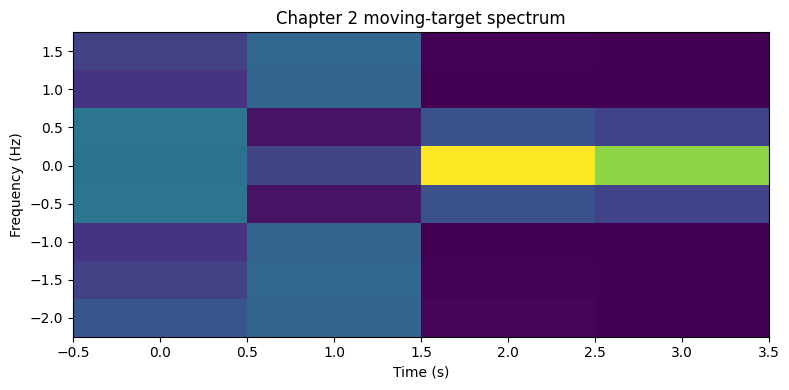

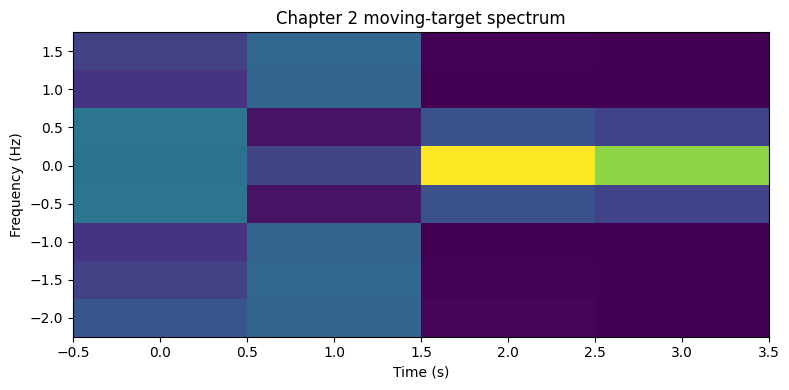

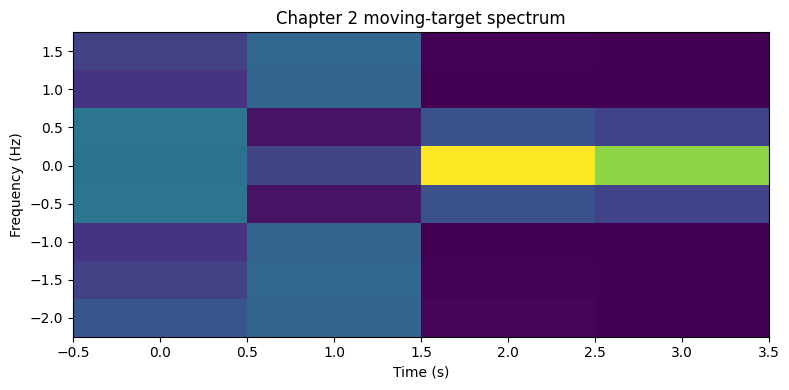

In [130]:
print("moving CSI shape:", csi_moving.shape)
print("STFT shape:", zxx.shape)
maybe_plot_spectrum(f, t, zxx, "Chapter 2 moving-target spectrum")

## Example 3: `acSim`-style internals

This lets you inspect the intermediate objects that the tutorial simulator produces.

In [131]:
paths = [
  PathSpec(aoa_deg=30.0, delay_s=30e-9, gain=1.0 + 0.0j),
  PathSpec(aoa_deg=110.0, delay_s=52e-9, gain=0.35 * np.exp(1j * 1.2)),
]
acsim_out = acsim_tutorial(paths, cfg, rng=np.random.default_rng(123))

In [132]:
print("true_csi shape:", acsim_out["true_csi"].shape)
print("chan_est shape:", acsim_out["chan_est"].shape)
print("noise estimate:", acsim_out["noise_est"])
print("signal estimate:", acsim_out["signal_est"])
print("mean abs channel estimation error:", float(np.mean(np.abs(acsim_out["true_csi"] - acsim_out["chan_est"]))))

true_csi shape: (56, 4)
chan_est shape: (56, 4)
noise estimate: 7.000257987791382e-33
signal estimate: 1.1056372960651006
mean abs channel estimation error: 0.03568658759141965


## Example 4: `mD-Track` path extraction

The original MATLAB call uses CSI shaped like `[Tx, Rx, Subcarrier]`.
We build that directly from the synthetic channel.

In [133]:
params = WLANParams()
paths_md = [
  np.array([35.0, 1.0, 10.0]),
  np.array([100.0, 1.0, 28.0]),
]

In [134]:
CSI_md = np.zeros((params.num_t_antenna, params.num_r_antenna, params.num_subcarrier), dtype=complex)

In [135]:
gains = [1.0 + 0.0j, 0.25 * np.exp(1j * 0.7)]

In [136]:
for info, gain in zip(paths_md, gains):
  CSI_md += compute_csi_mdtrack(params, info) * gain

In [137]:
md_result = md_track(CSI_md, num_path=2, params=params)

In [138]:
print("Estimated path info rows = [AOA_deg, AOD_deg, TOF_m]")
print(md_result)

Estimated path info rows = [AOA_deg, AOD_deg, TOF_m]
[[ 35. 100.]
 [  1.   1.]
 [ 10.  28.]]


## Interpretation guide

### What this notebook teaches well

- how CSI depends on path delay and angle
- why array geometry matters
- how OFDM pilots can be used to estimate CSI
- how simple AoA / ToF estimators work
- why a moving target becomes a time-frequency pattern
- how path peeling works in an mD-Track style algorithm

### What still differs from the MATLAB original

- the original `simulator.mlapp` uses true MATLAB ray tracing and WLAN toolbox primitives
- the tutorial `acsim_tutorial` uses a simplified OFDM pilot model
- `office.stl` is not used for real geometric ray tracing here

That tradeoff is intentional: the notebook stays runnable in plain Python while preserving the chapter's conceptual flow.